In [21]:
# Problem 1: Divide and Conquer – Merge Sort

In [2]:
def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    
    mid = len(arr)//2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    
    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0
    
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    
    result.extend(left[i:])
    result.extend(right[j:])
    return result

In [4]:
arr = [5, 2, 9, 1, 3]
print(merge_sort(arr))

[1, 2, 3, 5, 9]


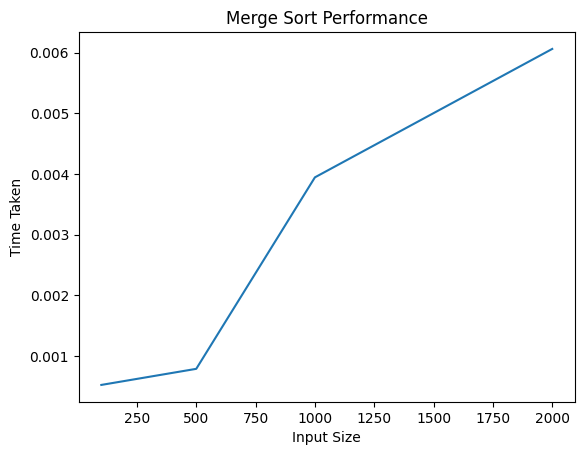

In [5]:
import time
import random
import matplotlib.pyplot as plt

sizes = [100, 500, 1000, 2000]
times = []

for n in sizes:
    arr = [random.randint(1, 1000) for _ in range(n)]
    
    start = time.time()
    merge_sort(arr)
    end = time.time()
    
    times.append(end - start)

plt.plot(sizes, times)
plt.xlabel("Input Size")
plt.ylabel("Time Taken")
plt.title("Merge Sort Performance")
plt.show()

### Explanation

Merge Sort is a Divide and Conquer algorithm.
It divides the array into smaller subarrays and then merges them in sorted order.

Time Complexity: O(n log n)
Space Complexity: O(n)

From the graph, we can observe that as input size increases, the time taken also increases gradually.
This shows the efficiency of Merge Sort for large datasets.

In [7]:
# Problem 2: Sorting Performance Comparison

In [8]:
def bubble_sort(arr):
    n = len(arr)
    
    for i in range(n):
        swapped = False  # optimization
        
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True
        
        if not swapped:
            break  # already sorted
    
    return arr

In [9]:
arr = [5, 2, 9, 1, 3]
print(bubble_sort(arr))

[1, 2, 3, 5, 9]


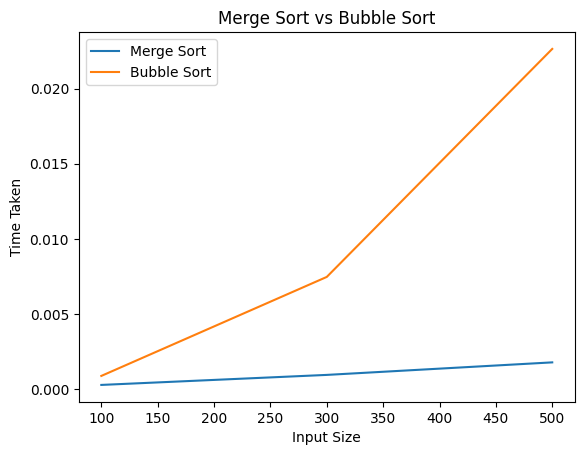

In [10]:
import time
import random
import matplotlib.pyplot as plt

sizes = [100, 300, 500]
merge_times = []
bubble_times = []

for n in sizes:
    arr = [random.randint(1, 1000) for _ in range(n)]
    
    # Merge Sort timing
    arr_copy = arr.copy()
    start = time.time()
    merge_sort(arr_copy)
    end = time.time()
    merge_times.append(end - start)
    
    # Bubble Sort timing
    arr_copy = arr.copy()
    start = time.time()
    bubble_sort(arr_copy)
    end = time.time()
    bubble_times.append(end - start)

# Plot
plt.plot(sizes, merge_times, label="Merge Sort")
plt.plot(sizes, bubble_times, label="Bubble Sort")

plt.xlabel("Input Size")
plt.ylabel("Time Taken")
plt.title("Merge Sort vs Bubble Sort")
plt.legend()
plt.show()

### Explanation

Bubble Sort has a time complexity of O(n²), which makes it slow for large datasets.

Merge Sort has a time complexity of O(n log n), making it much more efficient.

From the graph, we can clearly see that Bubble Sort takes more time as input size increases,
while Merge Sort performs better and scales efficiently.

In [12]:
# Problem 3: Greedy Algorithm – Fractional Knapsack

In [14]:
def fractional_knapsack(weights, values, capacity):
    items = list(zip(values, weights))
    
    # sort by value/weight ratio
    items.sort(key=lambda x: x[0]/x[1], reverse=True)
    
    total_value = 0
    
    for value, weight in items:
        if capacity >= weight:
            capacity -= weight
            total_value += value
        else:
            total_value += value * (capacity / weight)
            break
    
    return total_value

In [15]:
weights = [10, 20, 30]
values = [60, 100, 120]
capacity = 50

print(fractional_knapsack(weights, values, capacity))

240.0


In [16]:
# Problem 4: Dynamic Programming – 0/1 Knapsack

In [17]:
def knapsack_01(weights, values, capacity):
    n = len(values)
    
    # DP table
    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]
    
    for i in range(1, n + 1):
        for w in range(capacity + 1):
            if weights[i-1] <= w:
                dp[i][w] = max(
                    values[i-1] + dp[i-1][w - weights[i-1]],
                    dp[i-1][w]
                )
            else:
                dp[i][w] = dp[i-1][w]
    
    return dp[n][capacity]

In [18]:
weights = [10, 20, 30]
values = [60, 100, 120]
capacity = 50

print(knapsack_01(weights, values, capacity))

220


### Explanation

0/1 Knapsack is solved using Dynamic Programming.

It stores intermediate results in a table to avoid recomputation.

Time Complexity: O(nW)
Space Complexity: O(nW)

It guarantees an optimal solution but uses more memory compared to greedy methods.